In [1]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import process_probe as pp
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  pyr  sst  vip  coupling_index  normalized_depth  \
0           0           0    1    0    0             NaN               NaN   
1           0           0    1    0    0             NaN               NaN   
2           0           0    1    0    0             NaN               NaN   
3           0           4    0    0    0        0.206024          0.527778   
4           0           0    0    0    0             NaN               NaN   

   ...  burstIndex_Royer2012  burstIndex_Mizuseki2012  num_conn_e_to_e  \


### define session and hyperparameters

In [2]:
# Session obj contains stimulus, channel, and unit information
output_dir  = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022'
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)

# hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
seqlength = 750
num_epochs = 15 # 
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
batch_size = 32

### get spikes and LFP for active data

In [3]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
# spikes_obj.convolve_with_gaussian() # skip convolution
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.truncate(seqlength) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

100%|██████████| 8/8 [03:17<00:00, 24.72s/it]


### get spikes and LFP for spontaneous and passive data

In [7]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.truncate(seqlength)
# spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.minmax()

lfp_obj_spont = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.spontaneous_times[0],
                              session_obj.spontaneous_times[1], output_dir) 
lfp_obj_spont.filter_lfp(take_power = True)
lfp_obj_spont.downsample_lfp(5) # Downsample by 5
lfp_obj_spont.truncate(seqlength) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

# # get passive data
# spikes_obj_passive = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
# spikes_obj_passive.getSpkMat(session_obj.passive_times[0], session_obj.passive_times[1])
# spikes_obj_passive.truncate(seqlength)
# spikes_obj_passive.convolve_with_gaussian()
# spikes_obj_passive.zscore()

# lfp_obj_passive = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.passive_times[0],
#                                 session_obj.passive_times[1], output_dir)
# lfp_obj_passive.filter_lfp()
# lfp_obj_passive.downsample_lfp(5) # Downsample by 5
# lfp_obj_passive.truncate(seqlength) # Downsample by 5
# lfp_obj_passive.align_lfp(spikes_obj_passive.spkMat.shape[0])

100%|██████████| 8/8 [00:09<00:00,  1.16s/it]


### compare models on broadband activity from one channel 

In [4]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

In [59]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.7514
Linear regression test loss: 0.7562


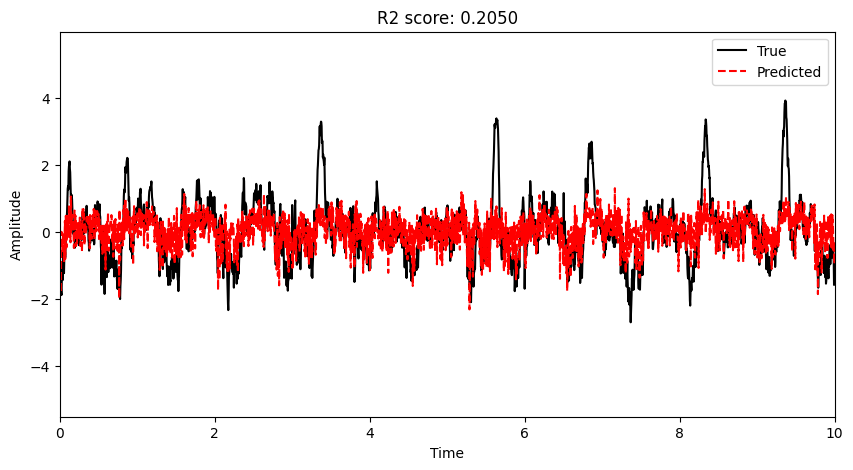

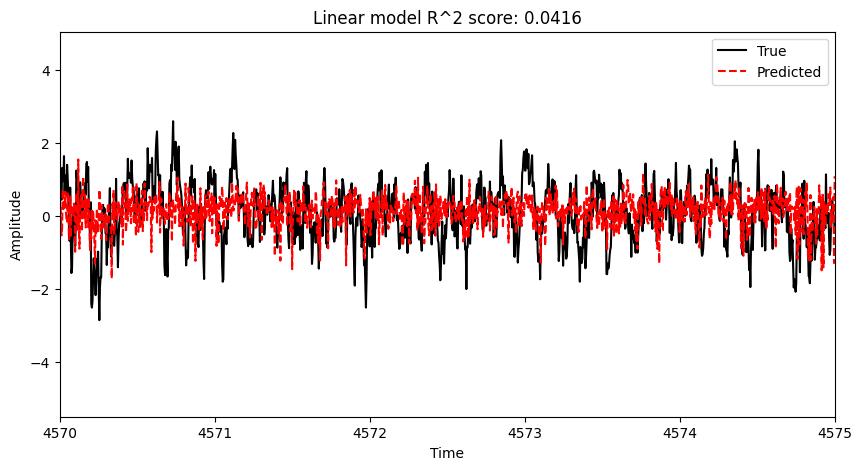

In [ ]:
# 3. Evaluate the linear model
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()


In [10]:
# GRU model
import importlib
importlib.reload(models)
import models as models

gru_model = models.process_model(models.GRUnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
gru_train_loss, gru_test_loss = gru_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'GRU  train loss: {gru_train_loss[-1]:.4f}')
print(f'GRU  test loss: {gru_test_loss[-1]:.4f}')

GRU  train loss: 0.2668
GRU  test loss: 0.2669


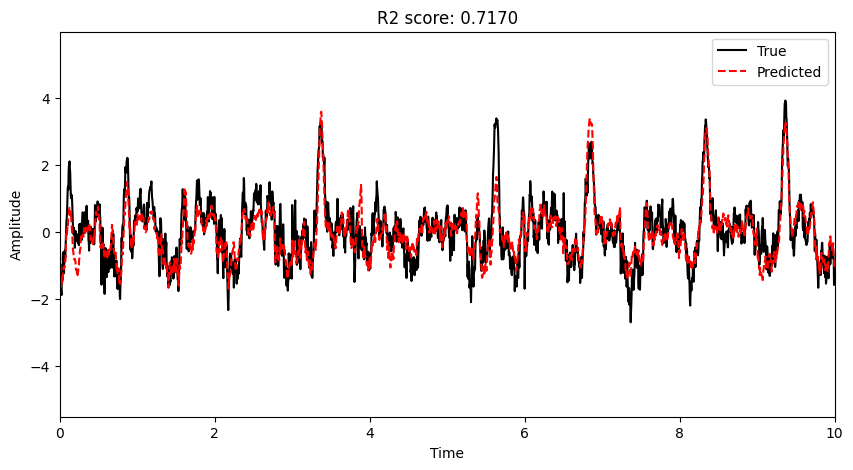

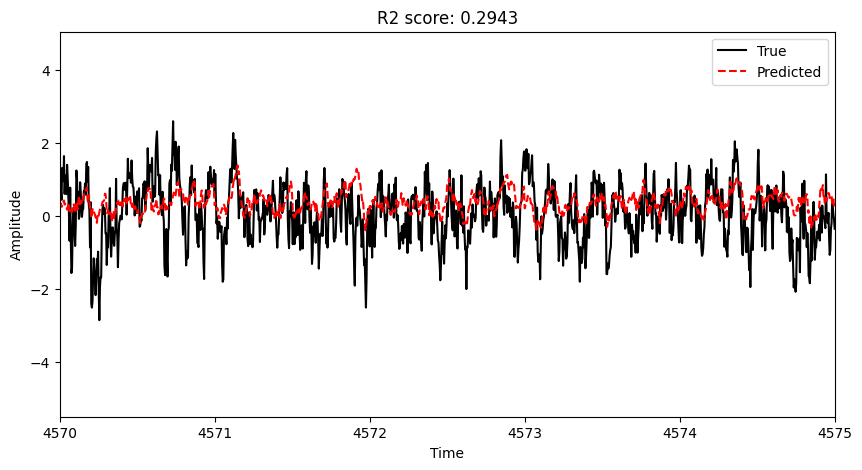

In [11]:
y_hat_test = gru_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
plt.show()

y_hat_spont = gru_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
plt.show()

In [19]:
# LSTM model
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=64 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.2029
LSTM  test loss: 0.2207


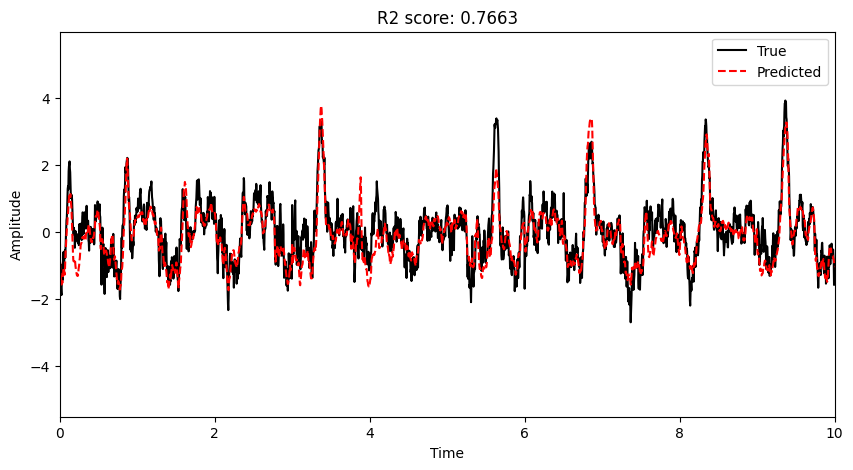

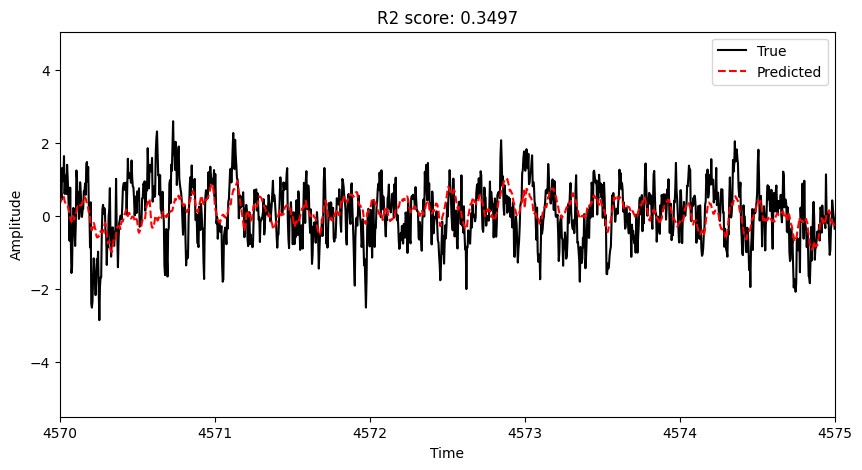

In [20]:
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
plt.show()

y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
plt.show()

In [31]:
def visualize_filters(model, num_neurons):
    """Visualizes the filters of the first convolutional layer in the model,
    arranged in a square grid.

    Args:
        model: Trained PyTorch model with a convolutional layer.

    """
    # Set model to evaluation mode
    model.eval()

    # Access the convolutional layer
    conv_layer = model.conv1d

    # Extract the filters
    filters = conv_layer.weight.data

    # Get the number of filters, input channels, and kernel size
    out_channels, in_channels, kernel_size = filters.shape
    print (f"Channels: {out_channels} in: {in_channels}, kernel {kernel_size}")

    # Calculate the number of rows and columns for a square grid
    num_filters = out_channels
    num_cols = int(np.ceil(np.sqrt(num_filters)))
    num_rows = int(np.ceil(num_filters / num_cols))

    # Create the subplots for the grid
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows), layout='constrained') # set scaling factor manually to fit
    fig.suptitle("Heat Maps of Convolutional Layer Filters", fontsize=16)

    # Iterate and plot each heatmap. Ensure out_channels and in_channels are not too large.
    for i in range(num_filters):
        # Get the row and column index of the current filter
        row_idx = i // num_cols
        col_idx = i % num_cols

        # Get single filter
        currentFilter = filters[i,:,:]

        # convert to numpy
        currentFilter = currentFilter.cpu().numpy()

        # Normalize if it is exploding
        currentMax = np.max(np.abs(currentFilter))
        if (currentMax > 100):
            currentFilter = currentFilter/currentMax

        # Plot Heatmap
        if num_rows == 1:
           im = axs[col_idx].imshow(currentFilter, cmap='viridis', aspect = "auto")
           axs[col_idx].set_title(f"Filt {i}")

           # Remove all ticks and labels
           axs[col_idx].set_xticks([])
           axs[col_idx].set_yticks([])
        elif num_cols == 1:
            im = axs[row_idx].imshow(currentFilter, cmap='viridis', aspect = "auto")
            axs[row_idx].set_title(f"Filt {i}")

           # Remove all ticks and labels
            axs[row_idx].set_xticks([])
            axs[row_idx].set_yticks([])
        else:
           im = axs[row_idx, col_idx].imshow(currentFilter, cmap='viridis', aspect = "auto")

            # Set Heatmap title
           axs[row_idx, col_idx].set_title(f"Filt {i}")

            # Remove all ticks and labels
           axs[row_idx, col_idx].set_xticks([])
           axs[row_idx, col_idx].set_yticks([])

        # fig.colorbar(im, ax=axs[-1,0]) # always puts the colorbar in same location

    # If num_filters is not a perfect square, then the final plots will show the heat map.
    for i in range(num_filters,num_rows * num_cols):
        row_idx = i // num_cols
        col_idx = i % num_cols

        if num_rows == 1:
            axs[col_idx].axis("off")
        elif num_cols == 1:
            axs[row_idx].axis("off")
        else:
            axs[row_idx,col_idx].axis("off")

    # Display plots
    plt.show()

Channels: 64 in: 623, kernel 5


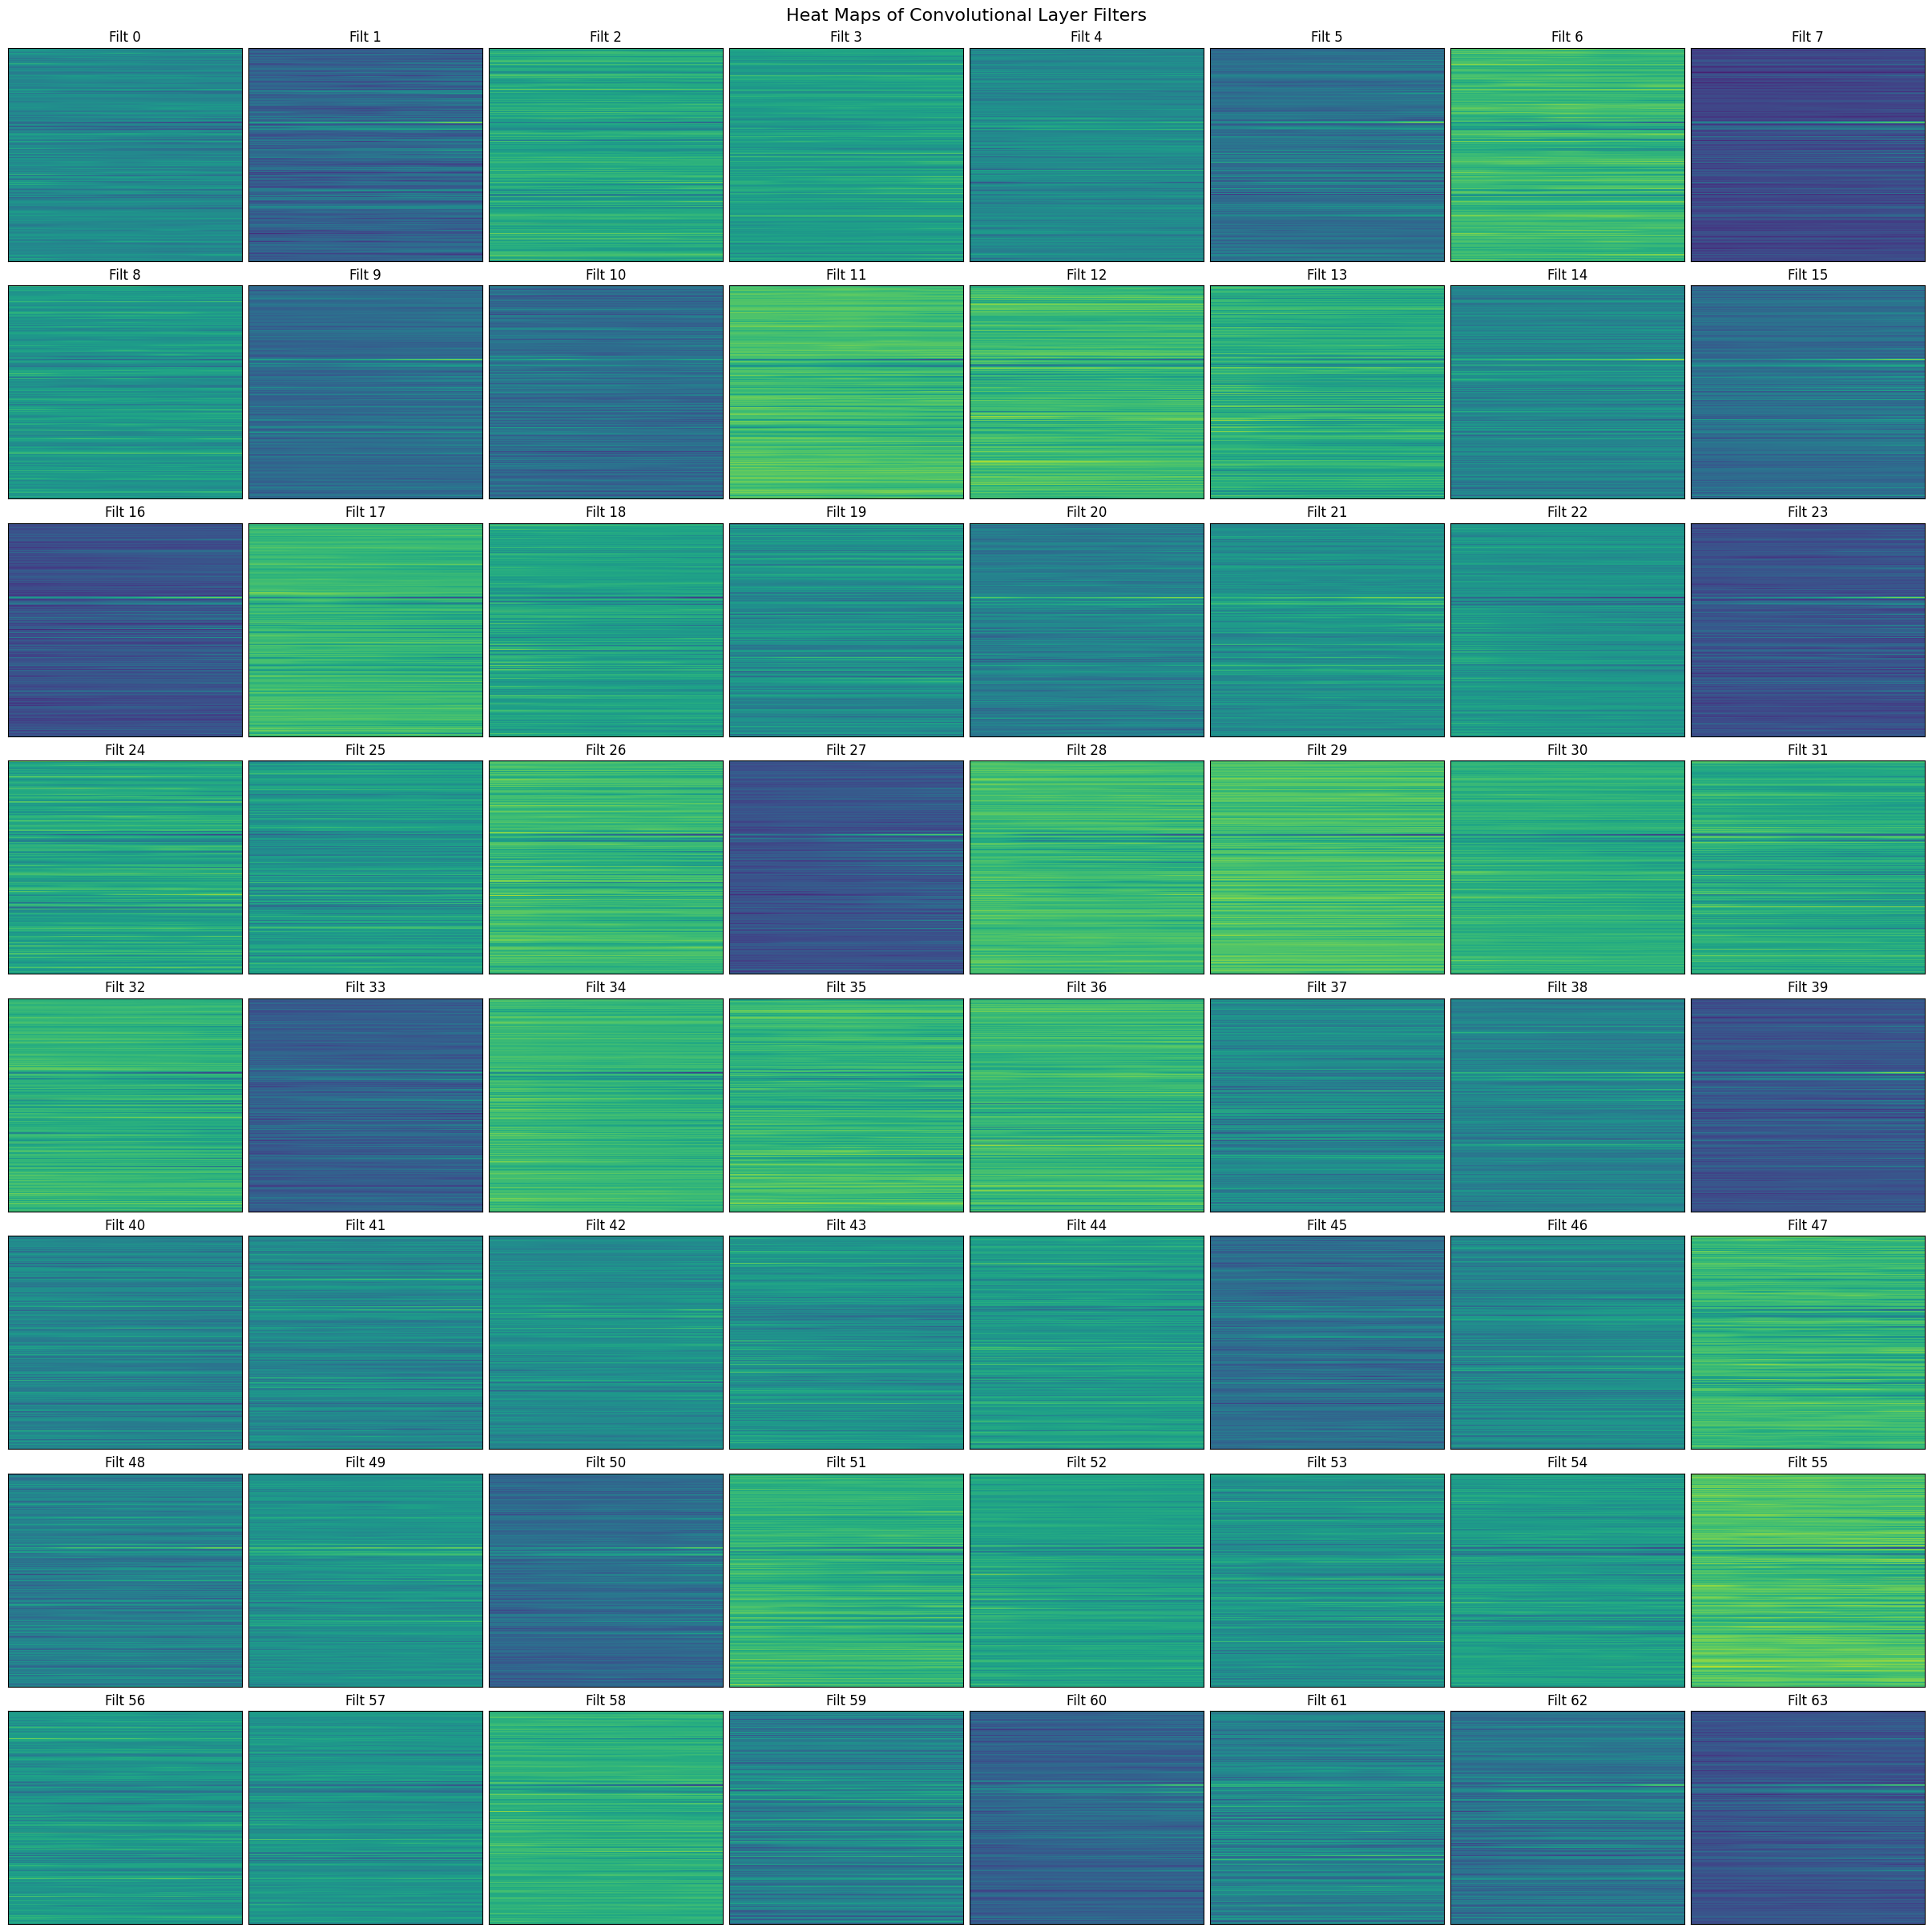

In [32]:
visualize_filters(lstm_model.model, input_size)

In [153]:
# transformer model
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = 64, num_heads = 8, 
                                                                   dropout=0.05), criterion, device)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.6905
transformer  test loss:  0.6570


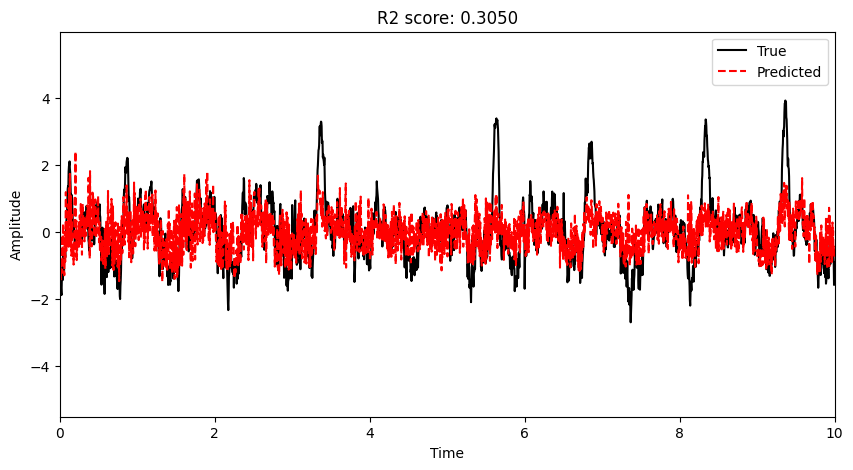

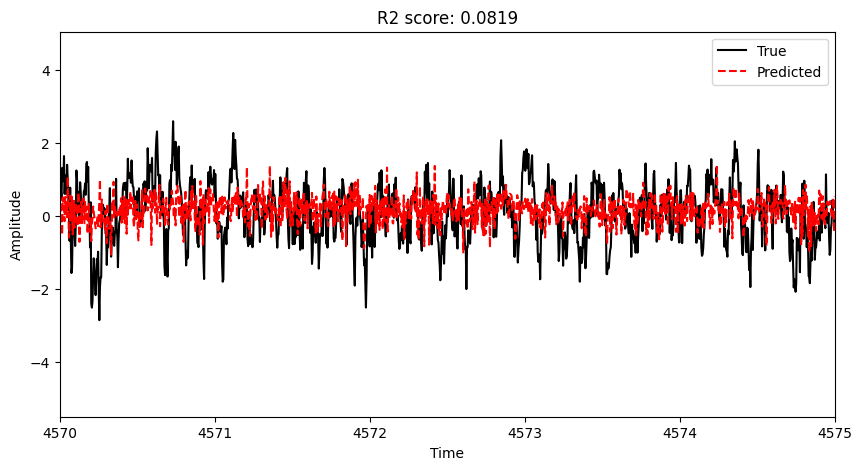

In [154]:
y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()

### investigate the hidden states of the LSTM model

In [112]:
# Initialize hidden state
h = torch.zeros(num_layers, 1, hidden_size).to(device)
c = torch.zeros(num_layers, 1, hidden_size).to(device)

hidden_states = []
cell_states = []

with torch.no_grad():
    for i in range(test_spikes.shape[0]):
        x = test_spikes[i].unsqueeze(0).unsqueeze(0).to(device)
        output, (h, c) = lstm_model.model.lstm(x, (h, c))
        hidden_states.append(h.squeeze(0).cpu().numpy())
        cell_states.append(c.squeeze(0).cpu().numpy())
        
hidden_states = np.array(hidden_states)
cell_states = np.array(cell_states)

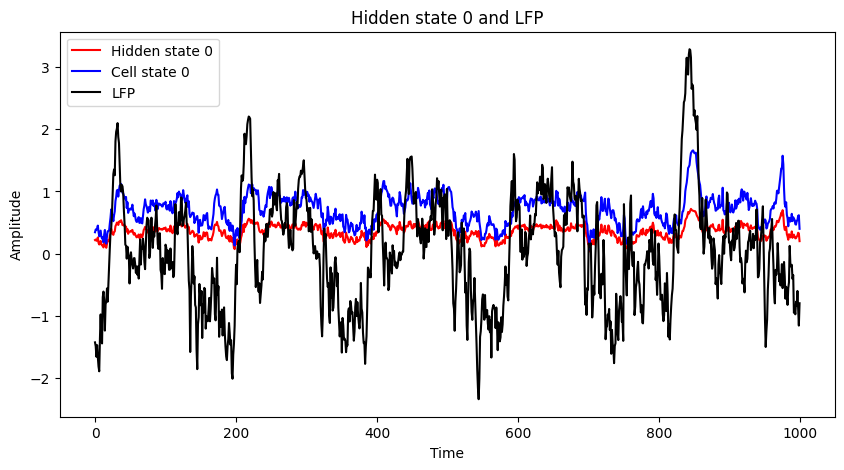

In [160]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(hidden_states[:1000,0, 0], 'r', label='Hidden state 0')
ax.plot(cell_states[:1000,0, 0], 'b', label='Cell state 0')
ax.plot(test_lfp[:1000].cpu().numpy(), 'k', label='LFP')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('Hidden state 0 and LFP')
plt.legend()
plt.show()

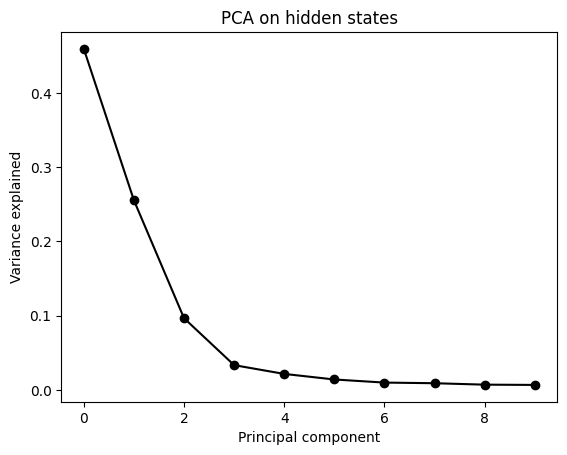

In [149]:
# do pca on hidden and cell states
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
pca.fit(hidden_states.reshape(-1, hidden_states.shape[-1]))
pca_hidden = pca.transform(hidden_states.reshape(-1, hidden_states.shape[-1]))

plt.plot(pca.explained_variance_ratio_, 'ko-')
plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.title('PCA on hidden states')
plt.show()

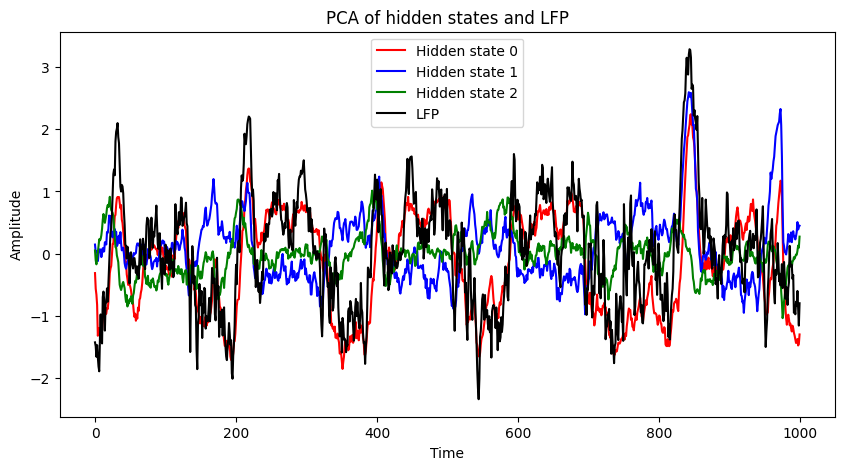

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(pca_hidden[:1000,0], 'r', label='Hidden state 0')
ax.plot(pca_hidden[:1000,1], 'b', label='Hidden state 1')
ax.plot(pca_hidden[:1000,2], 'g', label='Hidden state 2')
ax.plot(test_lfp[:1000].cpu().numpy(), 'k', label='LFP')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('PCA of hidden states and LFP')
plt.legend()
plt.show()

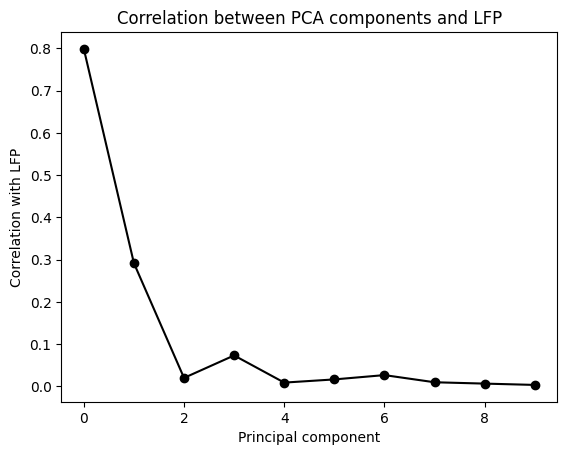

In [164]:
# plot the correlation between the PCA components and the LFP
from scipy.stats import pearsonr

lfp_hidden_corr = []
for i in range(pca_hidden.shape[1]):
    corr, _ = pearsonr(pca_hidden[:,i], test_lfp.cpu().numpy())
    lfp_hidden_corr.append(corr)

lfp_hidden_corr = np.array(lfp_hidden_corr)    
plt.plot(np.abs(lfp_hidden_corr), 'ko-')
plt.xlabel('Principal component')
plt.ylabel('Correlation with LFP')
plt.title('Correlation between PCA components and LFP')
plt.show()

### run the LSTM model on all channels and bands

In [18]:
lossesTrain, lossesTest = (np.zeros((len(lfp_obj.channels), num_epochs, len(bands)+1)) for _ in range(2))
R2_train, R2_test       = (np.zeros((len(lfp_obj.channels), len(bands)+1)) for _ in range(2))

# initialize dictionary to store trained models 
all_models = {}

for bandi in range(len(bands)+1):
    sys.stdout.write('\r' + 'Working on band ' + str(bandi + 1) + ' out of ' + str(len(bands)+1) + '\n')
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,:,bandi], 
                                                      seqlength, test_size=0.2, random_state=42)

    for chani in range(len(lfp_obj.channels)):
        sys.stdout.write('\t' + 'Training model for channel ' + str(chani+1) + ' out of ' + str(lfp_obj.lfpMat.shape[1]) + '\n')
        
        train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train[:,:,chani], y_test[:,:,chani], batch_size , device)
        
        model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
        
        train_loss, test_loss = model.train(train_dataloader,
                                        test_dataloader , num_epochs)
        
        yHat = model.evaluate(test_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_test[chani, bandi] = r2_score(test_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        yHat = model.evaluate(train_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_train[chani, bandi] = r2_score(train_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        
        lossesTrain[chani,:, bandi] = train_loss
        lossesTest[chani,:, bandi] = test_loss
        
        all_models[chani, bandi] = model


Working on band 1 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model for channel 4 out of 20
	Training model for channel 5 out of 20
	Training model for channel 6 out of 20
	Training model for channel 7 out of 20
	Training model for channel 8 out of 20
	Training model for channel 9 out of 20
	Training model for channel 10 out of 20
	Training model for channel 11 out of 20
	Training model for channel 12 out of 20
	Training model for channel 13 out of 20
	Training model for channel 14 out of 20
	Training model for channel 15 out of 20
	Training model for channel 16 out of 20
	Training model for channel 17 out of 20
	Training model for channel 18 out of 20
	Training model for channel 19 out of 20
	Training model for channel 20 out of 20
Working on band 2 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model

In [8]:
# get model predictions for the entire active session
yHat_active = np.zeros((lfp_obj.lfpMat.shape[0], lfp_obj.lfpMat.shape[1], len(bands)+1))
for chani in range(len(lfp_obj.channels)):
    for bandi in range(len(bands)+1):
        yHat_active[:,chani,bandi] = all_models[chani, bandi].evaluate(torch.tensor(spikes_obj.spkMat).float().to(device))

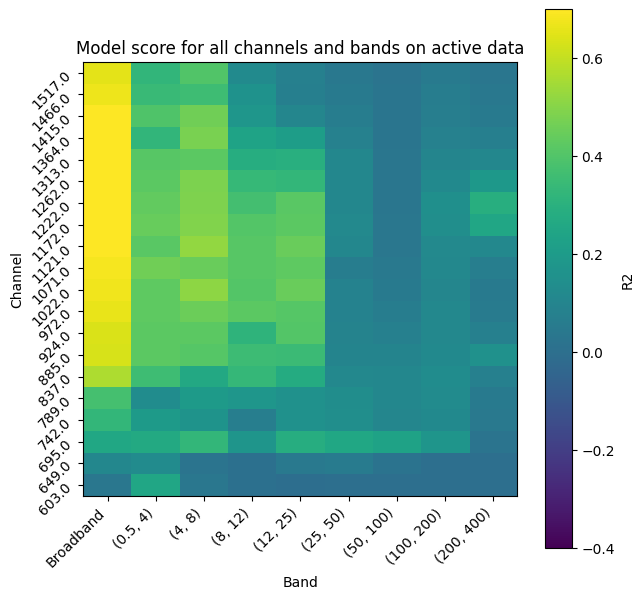

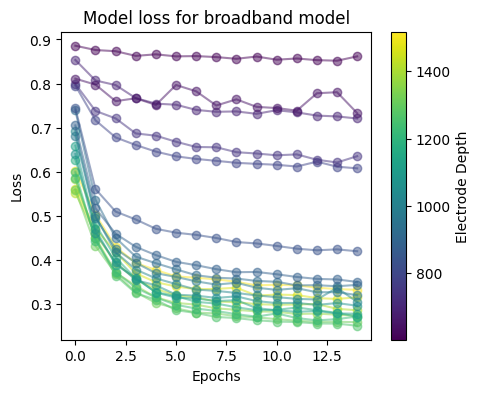

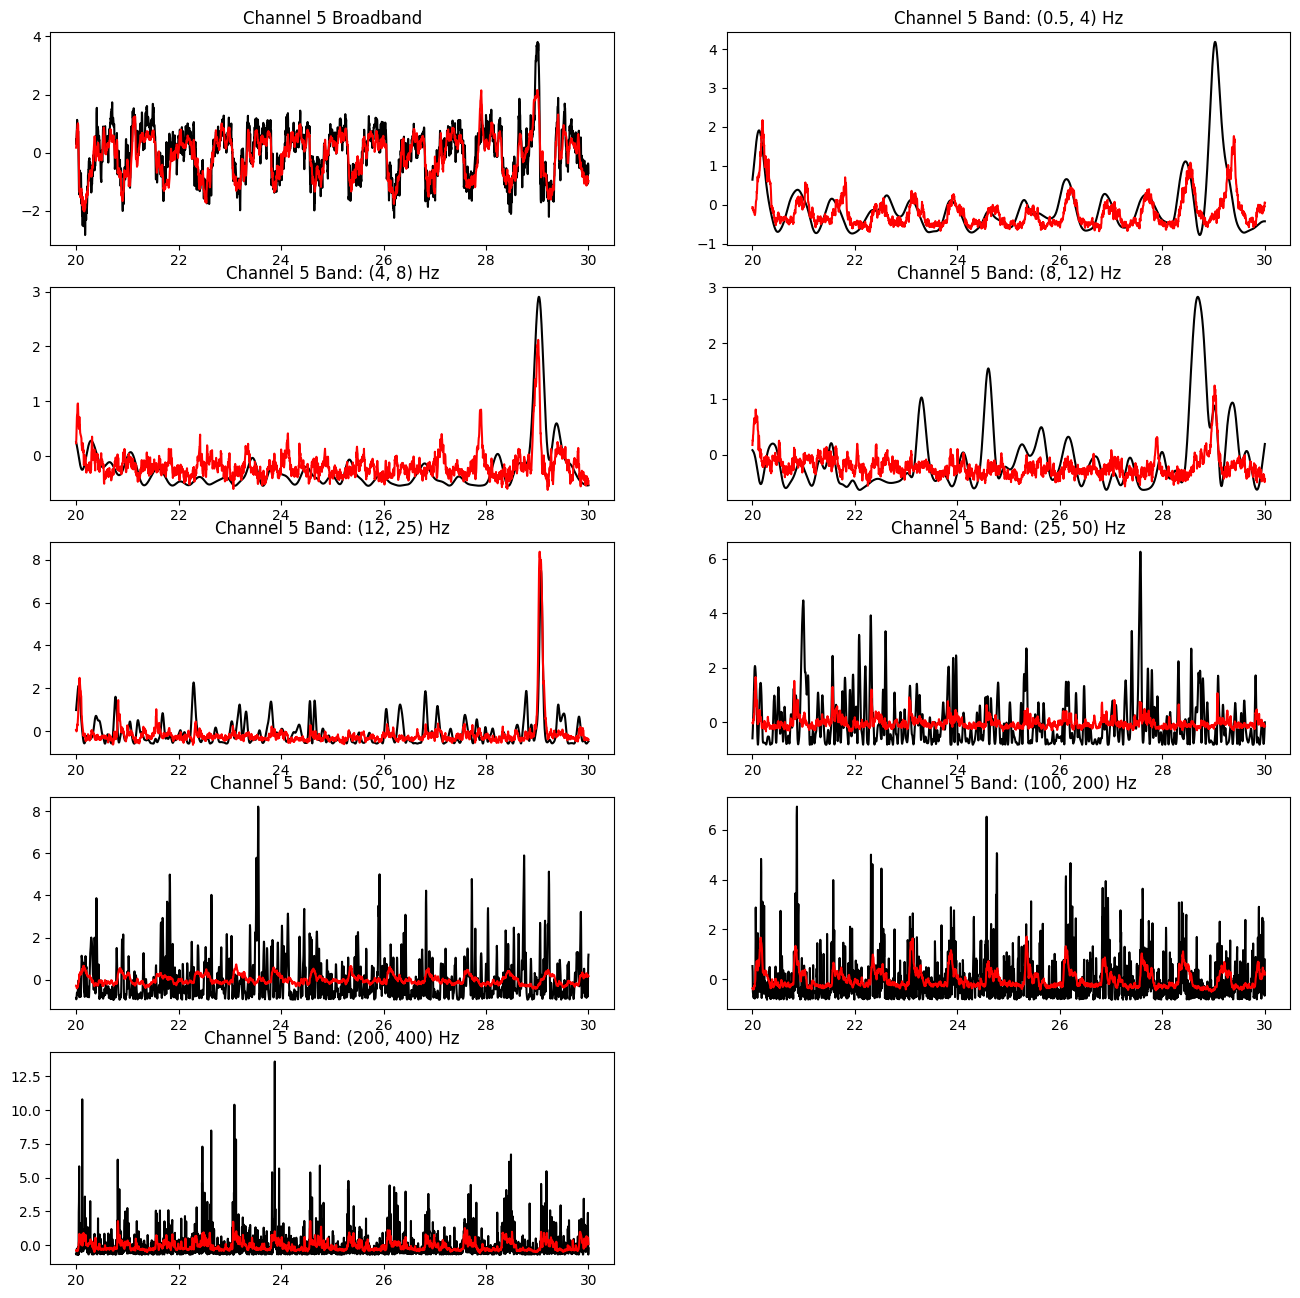

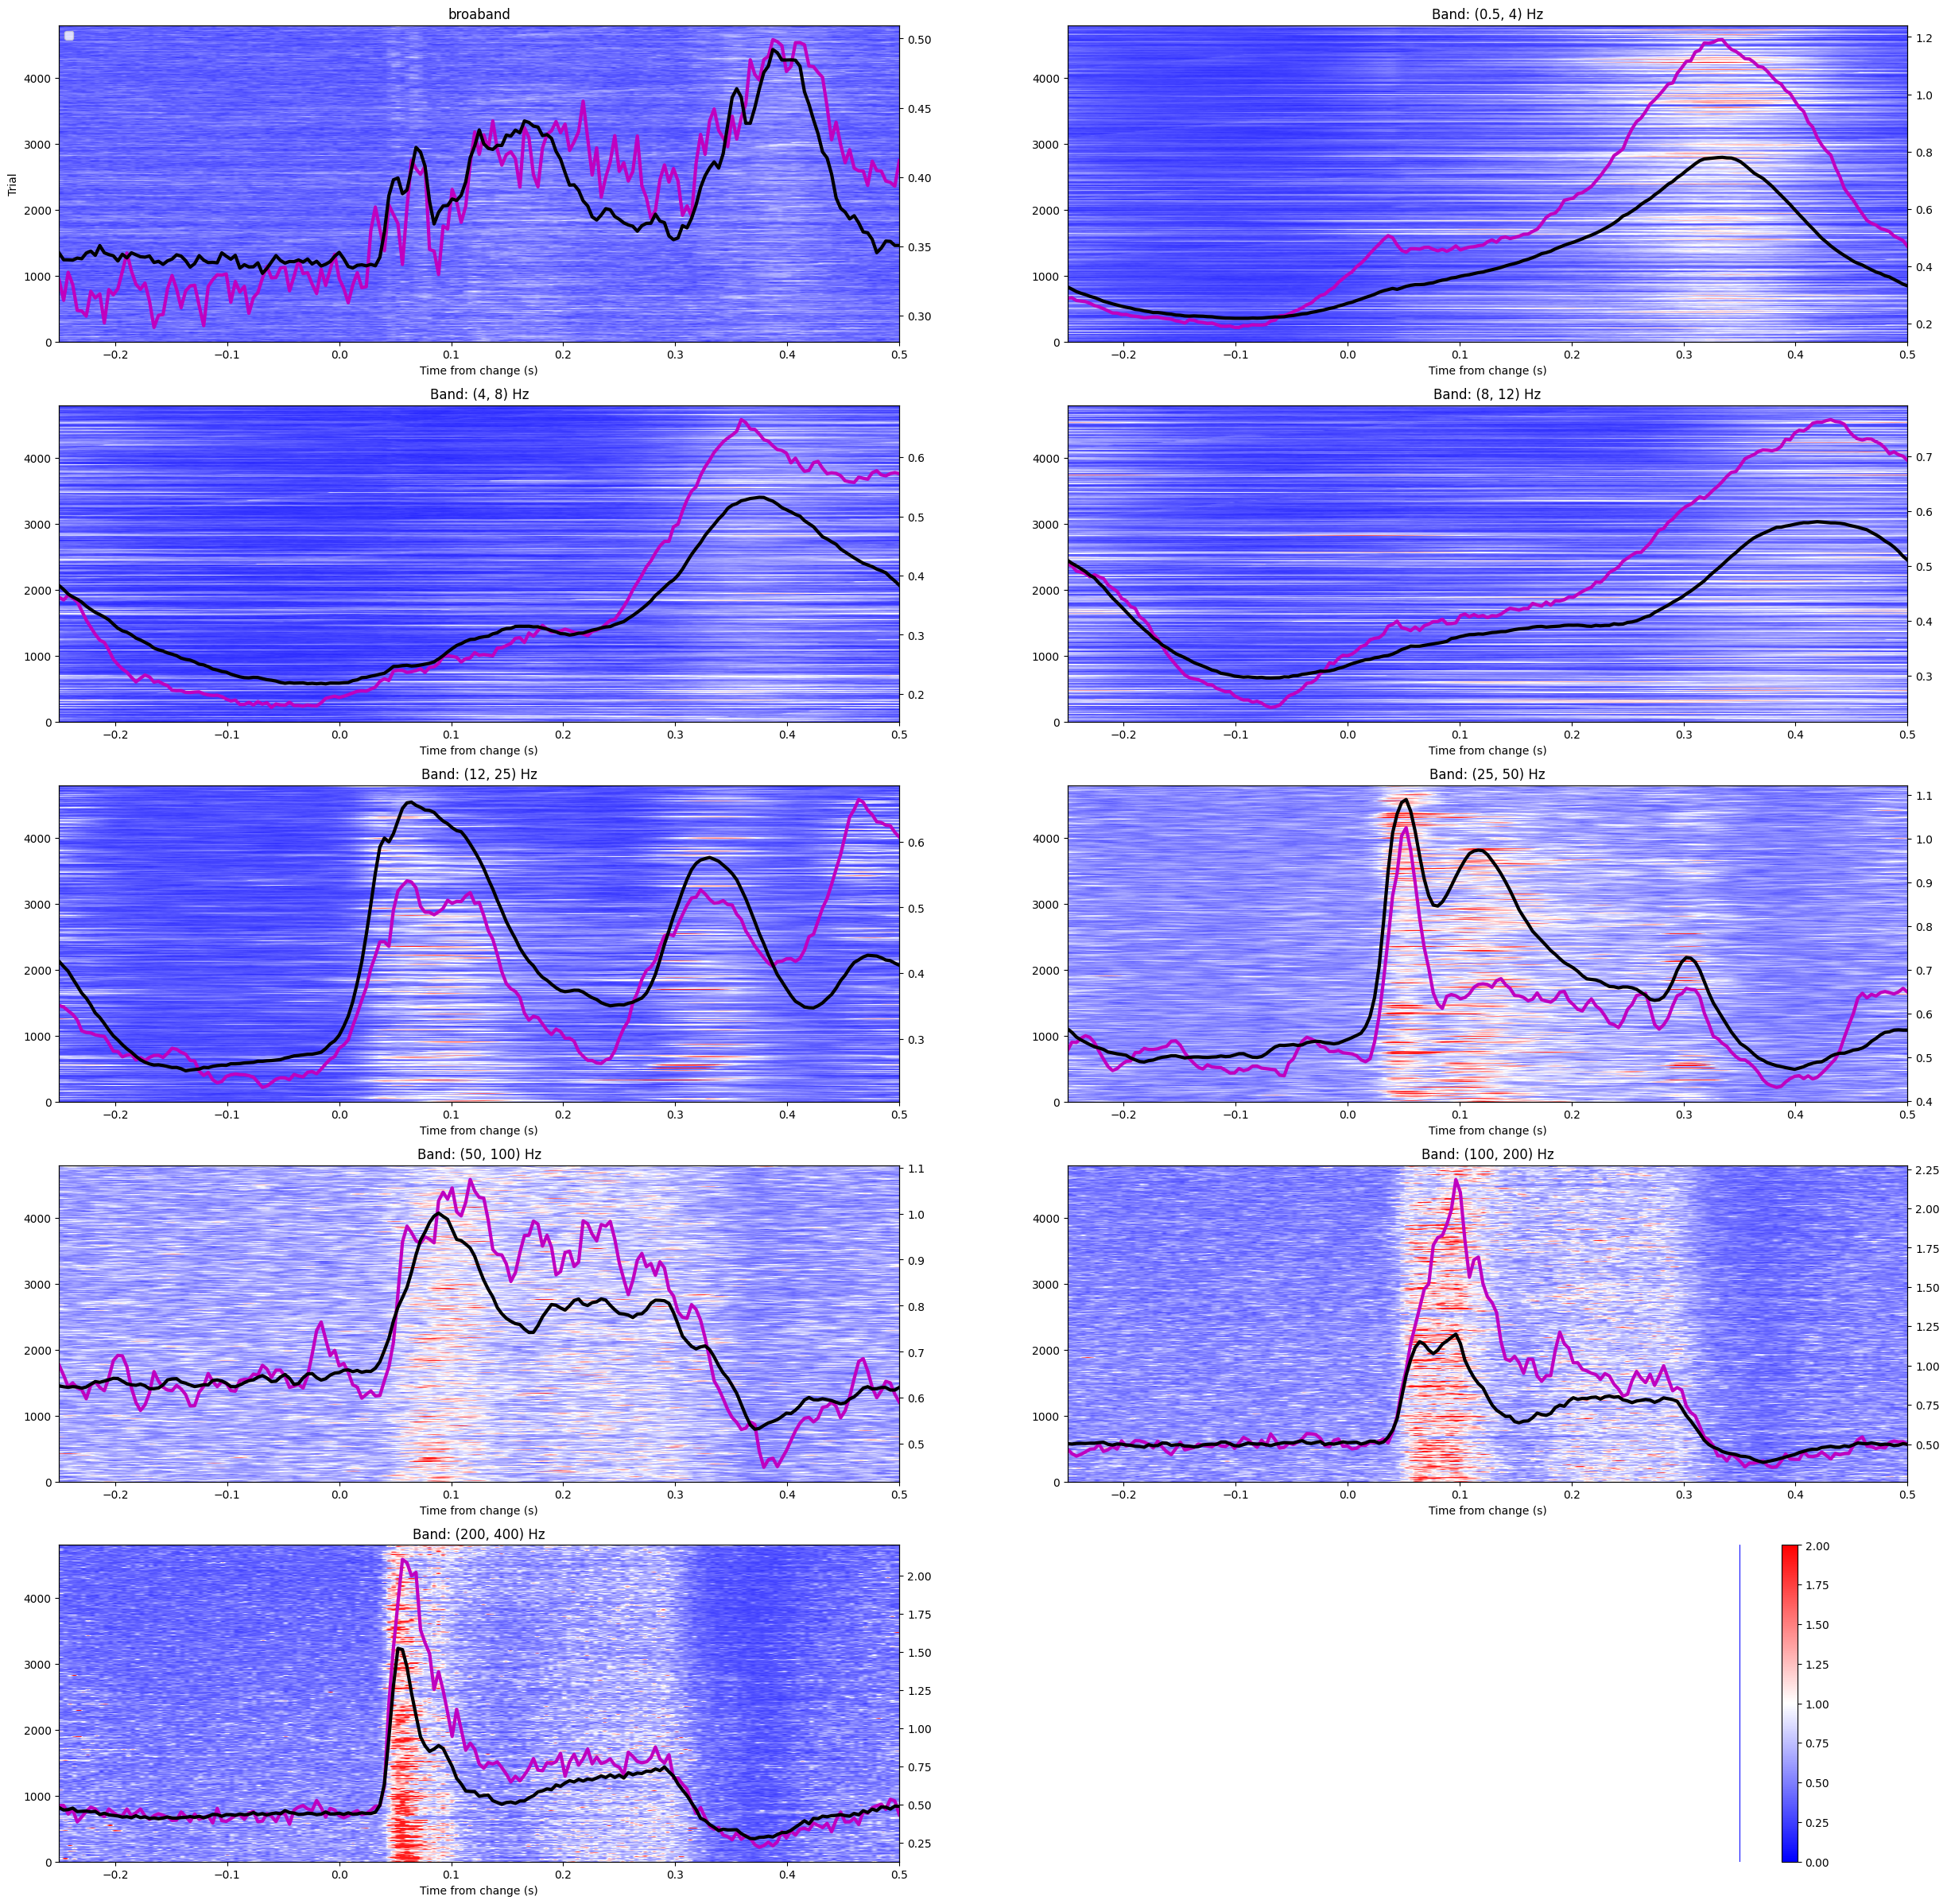

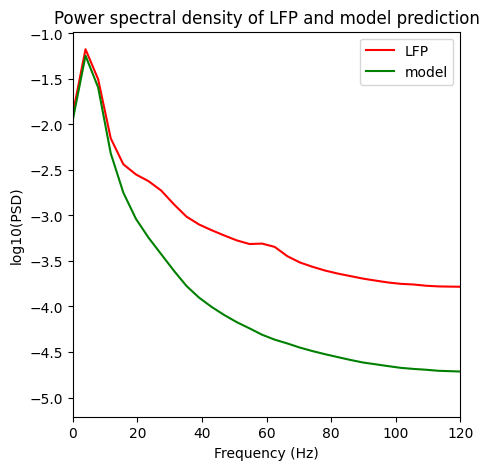

In [9]:
plot_r2(R2_test, lfp_obj.channels, bands)
plot_all_channel_loss(lfp_obj.channels, bands, 0, lossesTest)
plot_lfp_prediction(lfp_obj.lfpMat, yHat_active, 5, bands, start_time = 20, end_time = 30)
plot_abs_error_change(lfp_obj.lfpMat, yHat_active, session_obj, spikes_obj.timestamps, 5, bands)
plot_psd(lfp_obj.lfpMat, yHat_active, 5)

In [19]:
# save the models 
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
os.makedirs(output_dir_models, exist_ok=True)

for idx in range(len(all_models.keys())):
    chan = list(all_models.keys())[idx][0]
    band = list(all_models.keys())[idx][1]
    filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
    torch.save(all_models[chan, band].model.state_dict(), filename)

In [5]:
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)

# load the models if not in memory
if 'all_models' not in locals():
    all_models = {}
    for chan in range(num_channels):
        for band in range(len(bands)+1):
            filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
            model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
            model.model.load_state_dict(torch.load(filename))
            all_models[chan, band] = model
print('Models loaded from disk')

Models loaded from disk


In [9]:
os.makedirs(output_dir_models / 'attrs' , exist_ok=True)
from IntegratedGradient import IntegratedGradient
import tqdm

attr_dur = 720
X_attr = torch.tensor(spikes_obj.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)
X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])
mean_attribution = np.zeros((num_channels, len(bands)+1 , spikes_obj.spkMat.shape[1]))

for chani in range(4,num_channels):
    for bandi in range(len(bands)+1):
        model = all_models[chani, bandi]
        ig = IntegratedGradient(model.model.train().to(device), method='last time point')        
        attrs = np.zeros((num_trials, seqlength, input_size))
        for trl in tqdm.tqdm(range(num_trials)):
            attr = ig.attribute(X_attr[trl], baselines = 0, n_steps = 50)[0].squeeze(0).cpu().numpy()
            attrs[trl,:,:] = attr
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        # save the attribution scores for each channel and band    
        attrs = attrs.reshape(num_trials * seqlength, input_size)
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
        mean_attribution[chani, bandi, :] = np.mean(attrs, axis=0)
        np.save(filename, attrs.astype('float32'), allow_pickle=True)

100%|██████████| 240/240 [07:33<00:00,  1.89s/it]


In [13]:
# for each area, calculate the mean attribution across all channels and bands
areas = sorted(session_obj.units['structure_acronym'].unique())
attributions_areas = np.zeros((len(areas), len(bands)+1, num_channels))
for areai, area in enumerate(areas):
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            attributions_areas[areai, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])
            
# for each cluster, calculate the mean attribution across all channels and bands            
cluster_id = {1:[], 2:[], 3:[], 4:[], 5:[]}
for i in range(1,6):
    cluster_id[i] = list(df.unit_id[df['cluster_id'] == i])
    
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, num_channels))

for clusteri in range(1,6):
    for bandi in range(len(bands)+1):
        for chani in range(num_channels):
            ind = session_obj.units.index.isin(cluster_id[clusteri])
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])

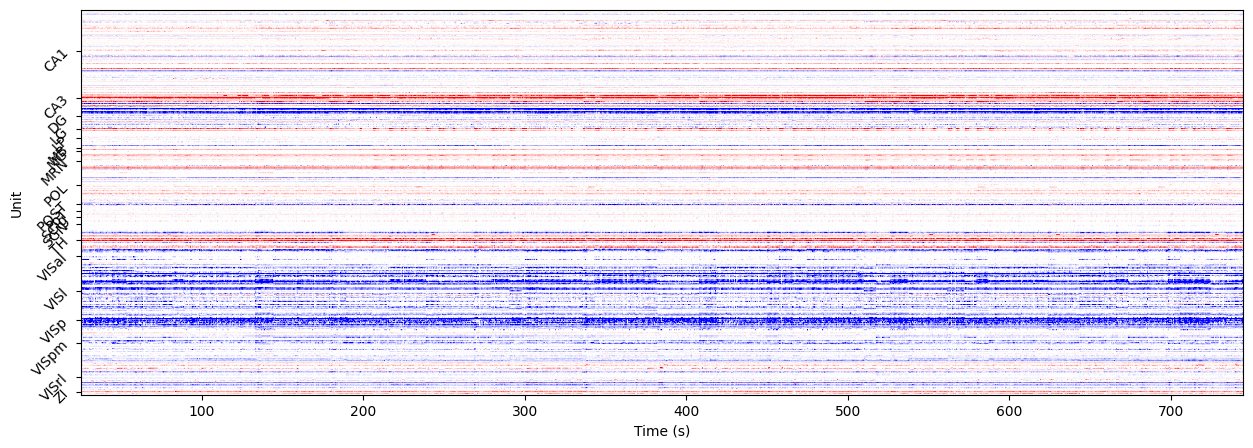

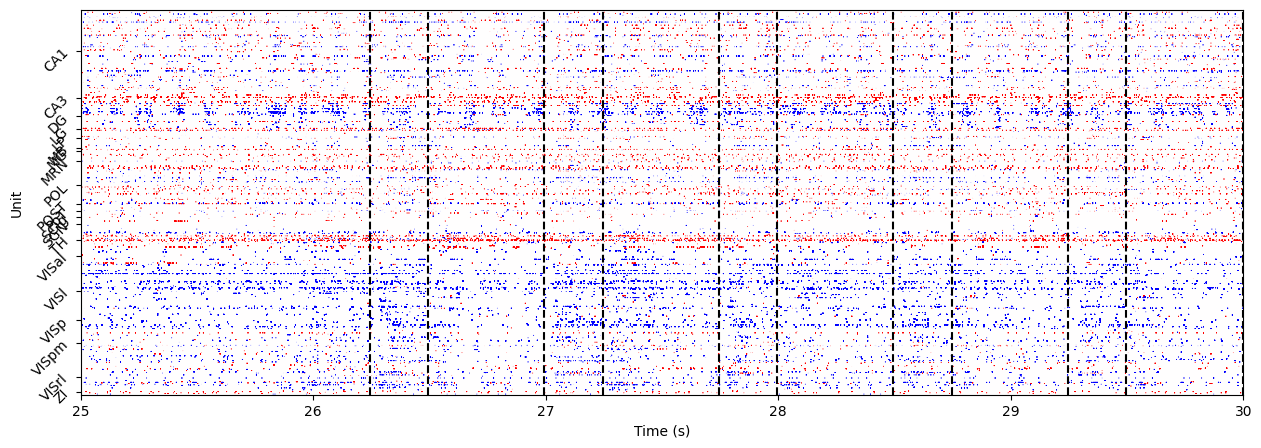

In [51]:
import importlib
import plots
importlib.reload(plots)
from plots import *

# plot_attr_density_plots(mean_attribution, session_obj, bands, 'VIS')
# plot_mean_attr_areas(attributions_areas, lfp_obj, session_obj, bands)
# plot_mean_attr_pyr_int(mean_attribution, session_obj, 'VIS', df, bands, 5)
# plot_mean_attr_clusters(mean_attr_clusters, lfp_obj , bands)

# plot broadband attributions 
chani = 5
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npy')

# plot_attr_corrmat(broadband_attr,session_obj)
plot_attr_matrix(broadband_attr, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0] + attr_dur])
plot_attr_matrix(broadband_attr, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0]+5], plot_stim = True)

# plot_attr_lfp_corr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj) # max sorting
# plot_attr_lfp_corr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj, sorting = "areas") # areas


In [52]:
# for each neuron, calculate the correlation between the attribution scores and the firing rate
unit_attr_fr_corr = np.zeros( (input_size ,num_channels, len(bands)+1))

for bandi in range(len(bands)+1):
    for chani in range(num_channels):
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
        attr = np.load(filename)
        mean1 = np.mean(attr.T, axis=1, keepdims=True)
        mean2 = np.mean(spikes_obj.spkMat[:int(attr_dur/bin_size),:].T, axis=1, keepdims=True)
        centered1 = attr.T - mean1
        centered2 = spikes_obj.spkMat[:int(attr_dur/bin_size),:].T - mean2
        covariance = np.sum(centered1 * centered2, axis=1)
        std1 = np.sqrt(np.sum(centered1**2, axis=1))
        std2 = np.sqrt(np.sum(centered2**2, axis=1))
        unit_attr_fr_corr[:, chani, bandi] = covariance / (std1 * std2)
            

KeyboardInterrupt: 

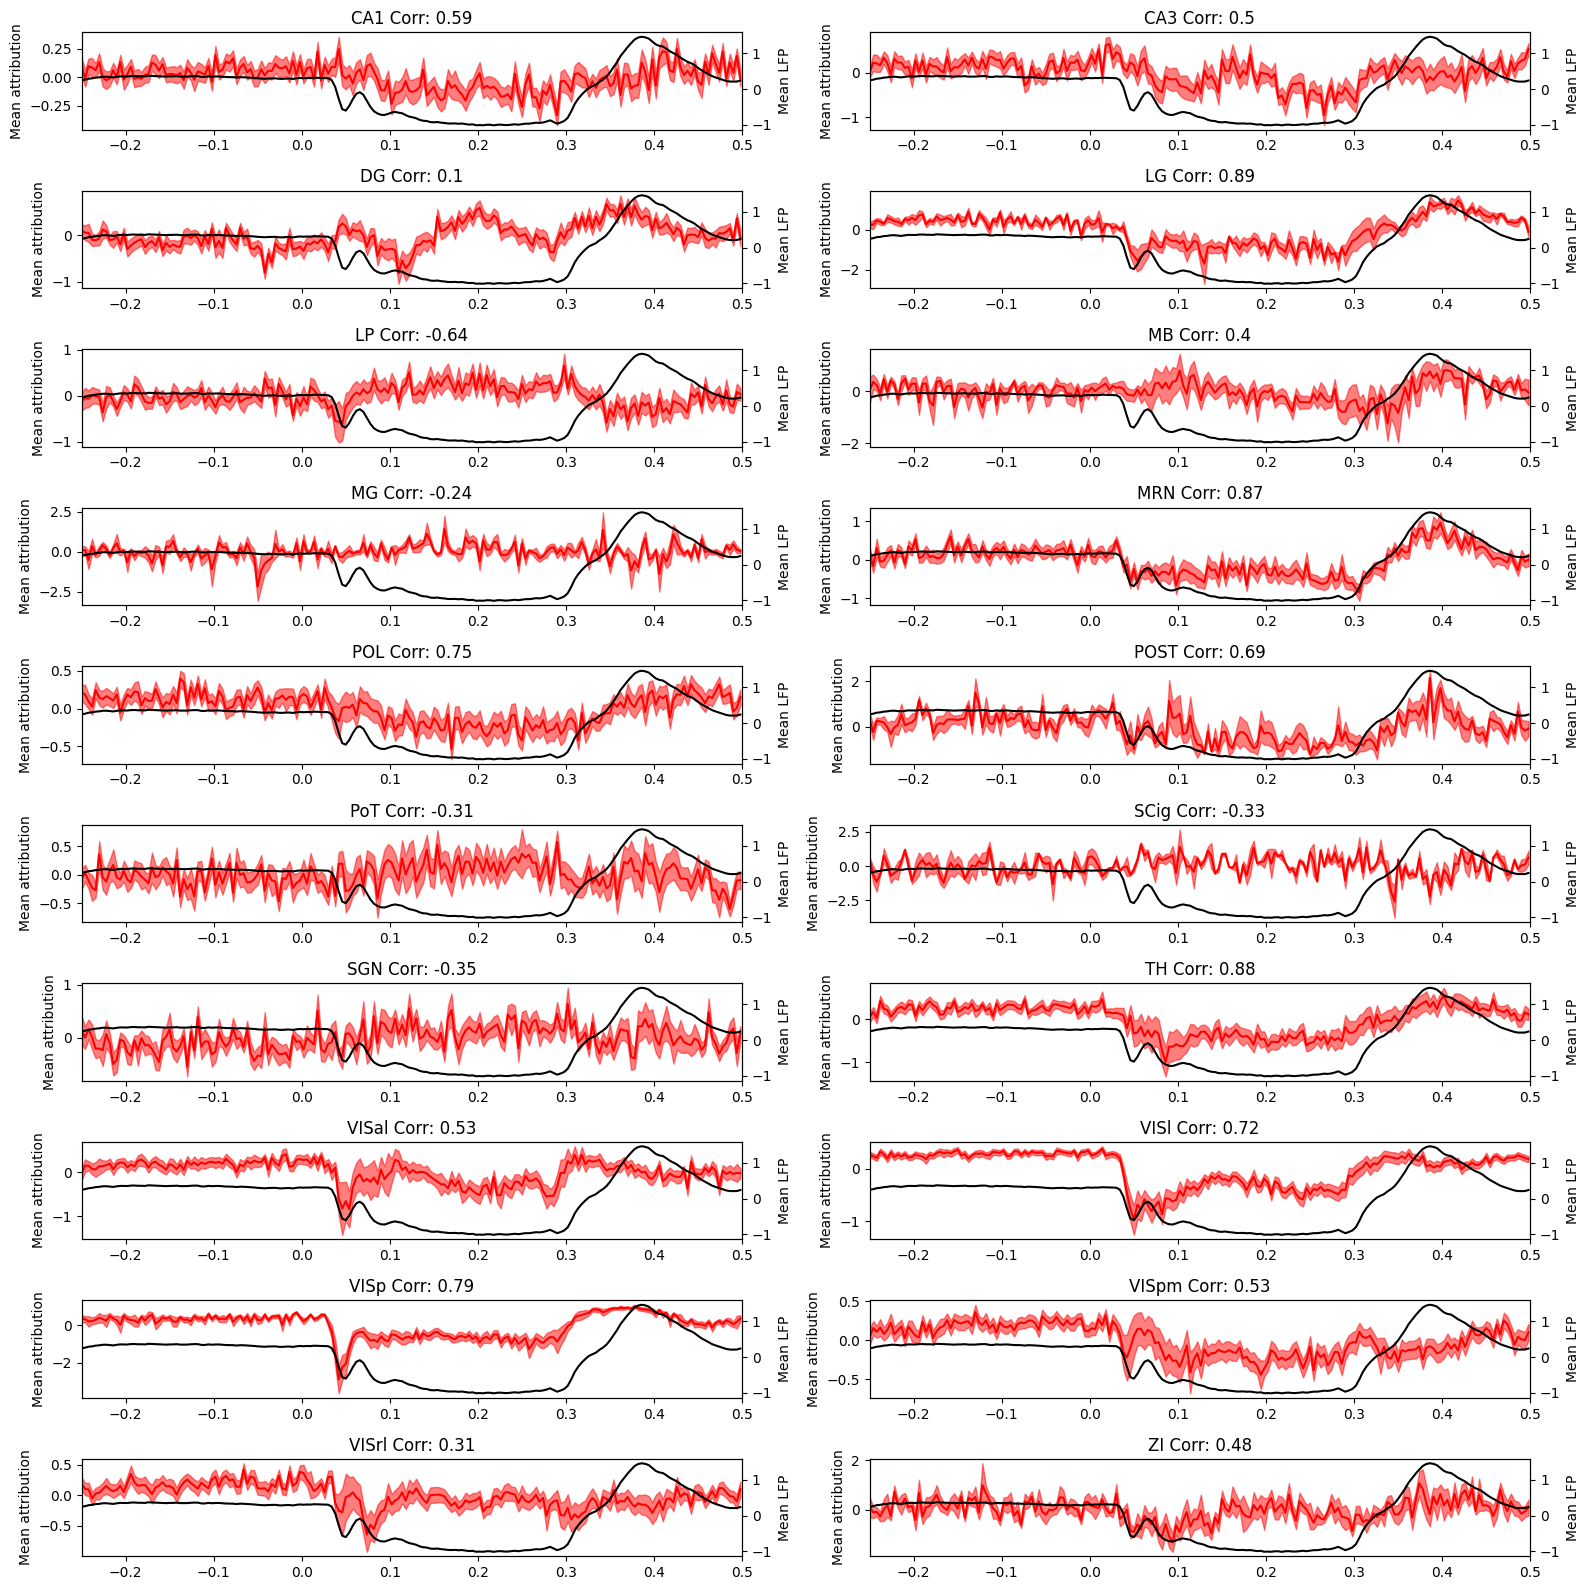

In [39]:
import importlib
import plots
importlib.reload(plots)
from plots import *

# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
attr_snippets, lfp_snippets, t = plot_peri_stim_attr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0], session_obj,
                    spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5])

max val: 0.005656778812408447, min val: -0.010747949592769146
Max neuron: 353, Min neuron: 216


Text(0, 0.5, 'Amplitude')

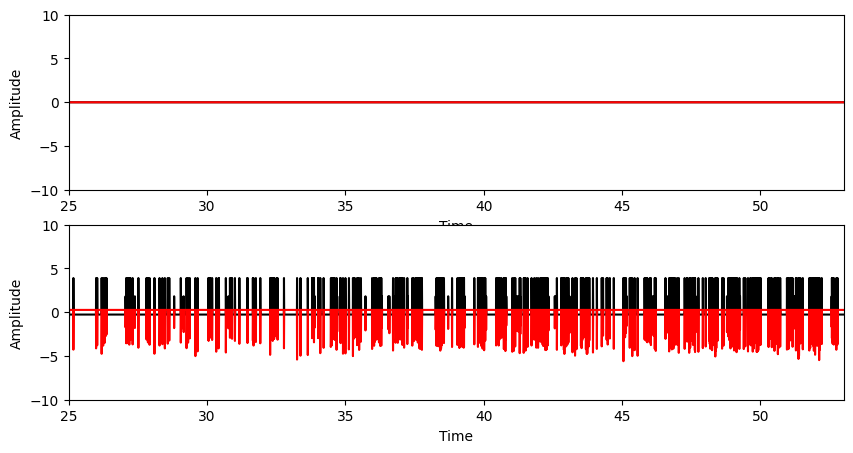

In [134]:
# find the neurons with the highest and lowest attribution scores 
max_neuron = np.argmax(np.mean(broadband_attr,axis=0)) # broadband channel 5
min_neuron = np.argmin(np.mean(broadband_attr,axis=0)) # broadband channel 5
max_val = np.max(np.mean(broadband_attr,axis=0))
min_val = np.min(np.mean(broadband_attr,axis=0))
print(f'max val: {max_val}, min val: {min_val}')    
print(f'Max neuron: {max_neuron}, Min neuron: {min_neuron}')

win = [0, 28]

max_neuron = 191


fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], 
           zscore(spikes_obj.spkMat[:int(attr_dur/bin_size),max_neuron]), 'k', label='firing rate')
ax[0].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)],
              zscore(broadband_attr[:,max_neuron]), 'r', label='attribution score')
ax[0].set_xlim([spikes_obj.timestamps[0]+win[0], spikes_obj.timestamps[0]+win[1]])
ax[0].set_ylim([-10, 10])
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Amplitude')

ax[1].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], 
           zscore(spikes_obj.spkMat[:int(attr_dur/bin_size),min_neuron]), 'k', label='firing rate')
ax[1].plot(spikes_obj.timestamps[:int(attr_dur/bin_size)],
              zscore(broadband_attr[:,min_neuron]), 'r', label='attribution score')
ax[1].set_xlim([spikes_obj.timestamps[0]+win[0], spikes_obj.timestamps[0]+win[1]])
ax[1].set_ylim([-10, 10])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Amplitude')

# plt.imshow(attr_snippets[:,:,max_neuron], aspect='auto', cmap='bwr', extent=[-0.25, 0.5, 0, attr_snippets.shape[0]],vmin=-1, vmax=1)
# plt.colorbar()
# plt.tight_layout()
# plt.show()

100%|██████████| 623/623 [00:00<00:00, 1767.51it/s]


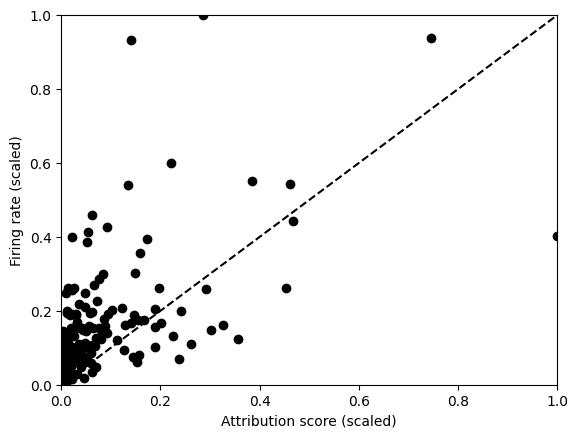

array([101, 191, 372, 440], dtype=int64)

In [169]:
vis = session_obj.units['structure_acronym'].str.contains('VIS')
vis_idx = np.where(vis)[0]
fr  = session_obj.units[session_obj.units['structure_acronym'].str.contains('VIS')].firing_rate.values

tmp_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=1)
tmp_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[0] + attr_dur)

fr2 = np.mean(tmp_obj.spkMat[:, vis], axis=0) / attr_dur # firing rate in Hz
fr2[fr2 == 0] = 1e-10 # avoid log(0)

# import minmax scaling function
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

plt.plot(scaler.fit_transform(np.mean(np.abs(broadband_attr), axis=0)[vis].reshape(-1,1)) , scaler.fit_transform(fr2.reshape(-1,1)), 'ok')
plt.plot([-1,1], [-1, 1], '--k')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('Attribution score (scaled)')
plt.ylabel('Firing rate (scaled)')
plt.show()

# find neurons with high firing rate but low attribution scores
high_fr_low_attr = np.where((np.log(fr) > 2) & (np.mean(np.abs(broadband_attr), axis=0)[vis] < 0.00001))[0]
vis_idx[high_fr_low_attr]

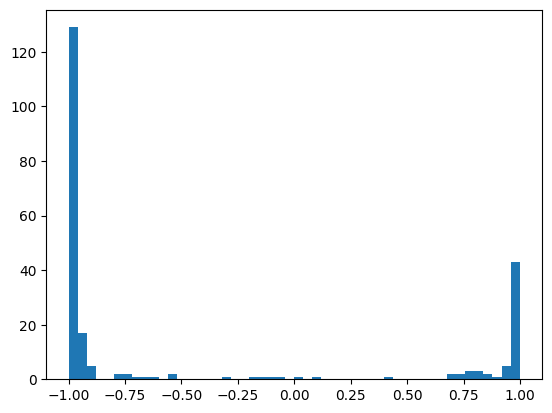

In [183]:
# fr_attr_corr = np.zeros(input_size)
# for celli in range(input_size):
#     fr_attr_corr[celli] = np.corrcoef(broadband_attr[:,celli], spikes_obj.spkMat[:int(attr_dur/bin_size),celli])[0,1] 
    
plt.hist((fr_attr_corr[vis]), bins=50)
plt.show()

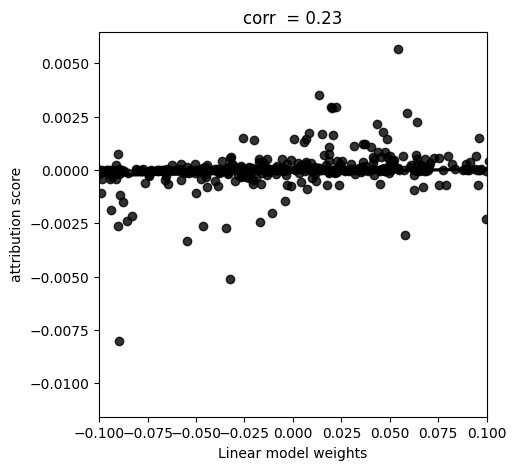

In [60]:
# correlation between attribution scores and linear model weights
weights = linear_model.model.coef_

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=weights, y=mean_attribution[5,0,:], ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(weights, mean_attribution[5,0,:])[0,1]:.2f}')
ax.set_xlim([-0.1, 0.1])
plt.show()